Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
10 odors tested
20 odors tested
30 odors tested
40 odors tested
50 odors tested
60 odors tested
70 odors tested
80 odors tested
90 odors tested
Simulation Duration = 1717.98900008s


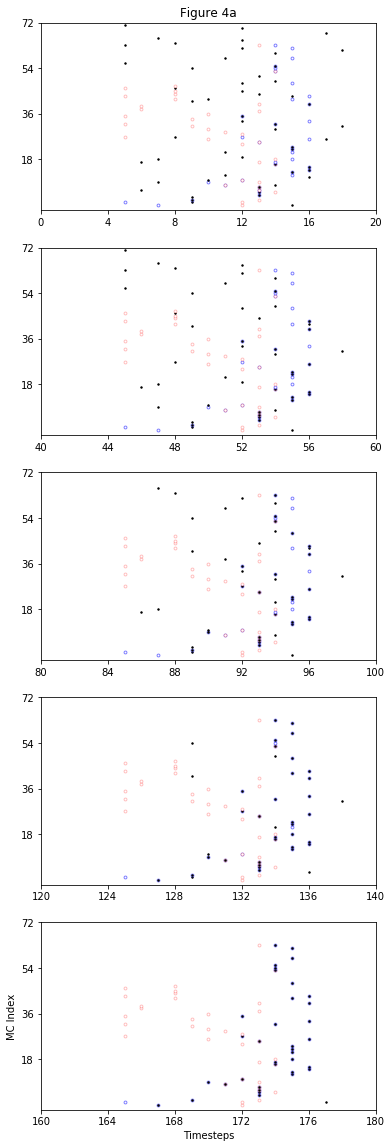

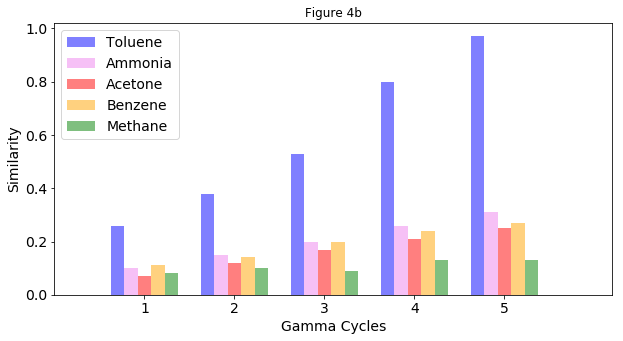

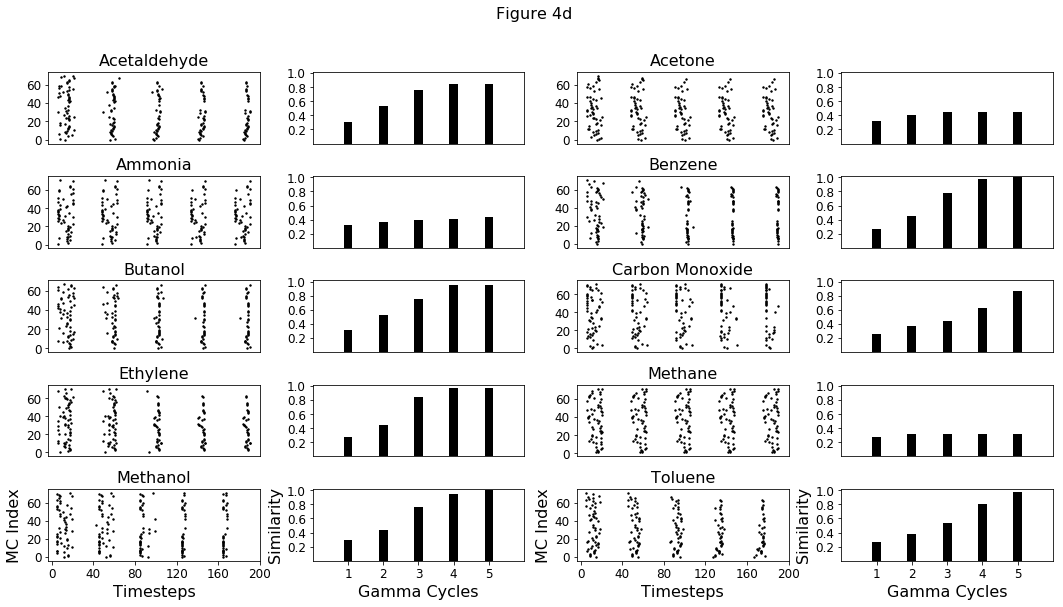

In [2]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import time
import pickle 

#Load Data
rf = open('./data/multiOdorTest.pi', 'r');
trainingOdors = np.array(pickle.load(rf));
testOdors = np.array(pickle.load(rf));
rf.close();
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
nGammaPerOdor = 5
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  

#Plots
plots.plotFigure4a(epl.gammaCode); 
plots.plotFigure4b(sMatrix); 
plots.plotFigure4d(epl.gammaCode, sMatrix); 


In [16]:
ignore = epl.gammaCode[4:100:10]

In [17]:
ignore

[[13,
  15,
  11,
  0,
  7,
  7,
  7,
  7,
  9,
  10,
  8,
  0,
  5,
  5,
  4,
  4,
  6,
  6,
  5,
  0,
  0,
  5,
  5,
  5,
  0,
  7,
  4,
  8,
  0,
  0,
  0,
  0,
  6,
  4,
  0,
  8,
  0,
  0,
  0,
  0,
  4,
  0,
  5,
  4,
  0,
  0,
  0,
  0,
  5,
  0,
  0,
  0,
  0,
  6,
  6,
  6,
  0,
  0,
  5,
  0,
  0,
  0,
  5,
  6,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [5,
  0,
  0,
  5,
  0,
  5,
  5,
  5,
  6,
  5,
  6,
  0,
  6,
  6,
  6,
  6,
  6,
  6,
  5,
  0,
  0,
  6,
  6,
  6,
  0,
  6,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  5,
  5,
  0,
  0,
  0,
  0,
  5,
  5,
  5,
  5,
  5,
  0,
  0,
  0,
  5,
  7,
  6,
  7,
  0,
  0,
  5,
  5,
  5,
  5,
  6,
  7,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [0,
  5,
  1,
  4,
  1,
  2,
  1,
  1,
  0,
  0,
  0,
  7,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  10,
  2,
  0,
  0,
  0,
  2,
  3,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  5,
  1,
  0,
  0,
  0,
  0,
  0,
  2,
  2,
  1,
  1,
  0,
  0,
  0,
  0,
  2,
  3,
  2,
  5,
  0,
  0,
  0

In [18]:
templatess = epl.gammaCode[9:100:10]

In [19]:
testing = epl.gammaCode[100:]
testingg = []
for x in range(0, len(testing), 5):
    testingg.append(testing[x+4])

# my Figure 5i

In [100]:
ypoints = [1]
templateID =5  # 4 and 5 are outliers
"""
10 is the number of occluded version of any given odor in testing (along levels of occlusion)
"""
for i in range(0,10):
    #ypoints.append(readout.jaccardSimilarity(templatess[0][4], testingg[i][4]))
    ypoints.append(readout.computeSimilarity(templatess[templateID], testingg[templateID*10 + i]))

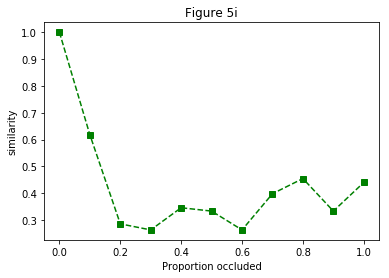

In [101]:
xpoints = np.linspace(0,1,11)
ypoints = np.array(ypoints)

import matplotlib.pyplot as plt
plt.plot(xpoints, ypoints, 's',ls = '--', c = 'g')
#plt.plot([0,xpoints[-1]], [.75, .75])
plt.xlabel('Proportion occluded')
plt.ylabel('similarity')
plt.title('Figure 5i')
plt.show()

In [67]:
ypoints = [1]
templateID = 9
"""
10 is the number of occluded version of any given odor in testing (along levels of occlusion)
"""
for i in range(0,10):
    #ypoints.append(readout.jaccardSimilarity(templatess[0][4], testingg[i][4])) 104, 154, 204
    ypoints.append(readout.computeSimilarity(epl.gammaCode[templateID*10+9], epl.gammaCode[104+i*5+templateID*50]))

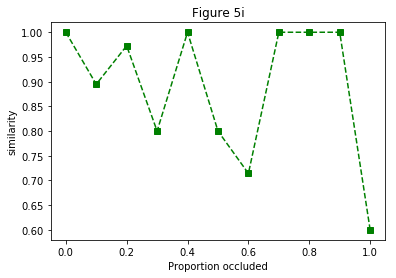

In [68]:
xpoints = np.linspace(0,1,11)
ypoints = np.array(ypoints)

import matplotlib.pyplot as plt
plt.plot(xpoints, ypoints, 's',ls = '--', c = 'g')
#plt.plot([0,xpoints[-1]], [.75, .75])
plt.xlabel('Proportion occluded')
plt.ylabel('similarity')
plt.title('Figure 5i')
plt.show()

In [77]:
epl.gammaCode[168]

[5,
 0,
 0,
 5,
 0,
 5,
 5,
 5,
 6,
 5,
 6,
 0,
 6,
 6,
 6,
 5,
 6,
 6,
 5,
 0,
 0,
 6,
 6,
 6,
 0,
 6,
 0,
 0,
 0,
 0,
 0,
 0,
 7,
 0,
 0,
 0,
 0,
 0,
 5,
 5,
 0,
 0,
 0,
 0,
 5,
 5,
 5,
 0,
 0,
 0,
 0,
 0,
 5,
 7,
 6,
 7,
 0,
 0,
 5,
 5,
 5,
 0,
 6,
 7,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

<BarContainer object of 10 artists>

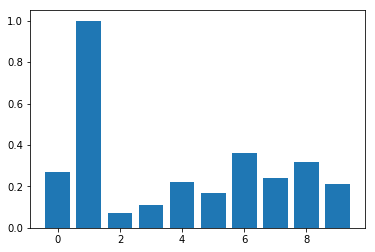

In [119]:
plt.bar(range(10),sMatrix[4+nGammaPerOdor*19])

In [127]:
sMatrix[4:nGammaPerOdor*10:nGammaPerOdor]

[[0.97, 0.27, 0.13, 0.1, 0.31, 0.25, 0.38, 0.26, 0.36, 0.2],
 [0.92, 0.25, 0.12, 0.09, 0.3, 0.23, 0.37, 0.24, 0.35, 0.19],
 [0.92, 0.26, 0.13, 0.1, 0.31, 0.24, 0.36, 0.26, 0.35, 0.2],
 [0.85, 0.25, 0.11, 0.08, 0.29, 0.23, 0.36, 0.23, 0.37, 0.19],
 [0.73, 0.29, 0.13, 0.1, 0.26, 0.23, 0.32, 0.25, 0.36, 0.21],
 [0.52, 0.23, 0.11, 0.07, 0.19, 0.2, 0.24, 0.2, 0.29, 0.19],
 [0.89, 0.27, 0.11, 0.08, 0.32, 0.24, 0.36, 0.24, 0.35, 0.2],
 [0.89, 0.27, 0.13, 0.11, 0.29, 0.25, 0.38, 0.27, 0.35, 0.21],
 [0.92, 0.27, 0.12, 0.09, 0.31, 0.24, 0.38, 0.25, 0.38, 0.2],
 [0.24, 0.15, 0.1, 0.09, 0.15, 0.13, 0.17, 0.17, 0.18, 0.13]]

In [131]:
np.array(sMatrix[4+nGammaPerOdor*10:nGammaPerOdor*20:nGammaPerOdor])>.75

array([[False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False]])

In [121]:
range(4,nGammaPerOdor*10,nGammaPerOdor)

[4, 9, 14, 19, 24, 29, 34, 39, 44, 49]